# Fit SSMR baseline model

In [261]:
import jax
import jax.numpy as jnp
import logging
logging.getLogger('jax').setLevel(logging.ERROR)
jax.config.update('jax_platform_name', 'cpu')
jax.config.update("jax_enable_x64", False)

import numpy as np
import pandas as pd

import os
import glob
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import sys
sys.path.append("../src/executor/executor")
from utils.ssm import DelaySSM, generate_ssm_predictions, generate_ssmr_predictions, get_residual_labels
from utils.residual import ResidualBr, PolyBr
from utils.models import SSMR

from filter_data import filter_data # Patrick added this import to use the filter function

In [262]:
def set_3D_axes_equal(ax):
    """
    Make axes of 3D plot have equal scale so that spheres appear as spheres,
    cubes as cubes, etc.
    """
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = (x_limits[0] + x_limits[1]) / 2
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = (y_limits[0] + y_limits[1]) / 2
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = (z_limits[0] + z_limits[1]) / 2

    # The plot bounding box is a sphere in the sense of the infinity norm, hence radius
    plot_radius = 0.5*max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

def plot_trajectories(trajs, ts):
    """
    Plot trajectories of observations.
    """
    traj_colormap = plt.cm.cool
    traj_linewidth = 1
    colors = [traj_colormap(i / len(trajs)) for i in range(len(trajs))]
    _, axs = plt.subplots(trajs.shape[1], 1, figsize=(6, 4), sharex=True)

    # Determine if the trajectories are 2D or 3D
    is_3d = trajs.shape[1] == 3
    
    if is_3d:
        axs[0].set_ylabel(r'$x_1$')
        axs[1].set_ylabel(r'$x_2$')
        axs[2].set_ylabel(r'$x_3$')
    else:
        axs[0].set_ylabel(r'$x_1$')
        axs[1].set_ylabel(r'$x_2$')

    for i, traj in enumerate(trajs):
        for j in range(trajs.shape[1]):
            axs[j].plot(ts, traj[j, :], color=colors[i], lw=traj_linewidth)
    axs[-1].set_xlabel(r'$t$')
    plt.tight_layout()
    if is_3d:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
        for i, traj in enumerate(trajs):
            ax.plot(traj[0, :], traj[1, :], traj[2, :], color=colors[i], lw=traj_linewidth)
        ax.set_xlabel(r'$x_1$')
        ax.set_ylabel(r'$x_2$')
        ax.set_zlabel(r'$x_3$')
        set_3D_axes_equal(ax)
    else:
        plt.figure(figsize=(4, 4))
        plt.xlabel(r'$x_1$')
        plt.ylabel(r'$x_2$')
        for i, traj in enumerate(trajs):
            plt.plot(traj[0, :], traj[1, :], color=colors[i], lw=traj_linewidth)
        plt.axis('equal')
    plt.tight_layout()

def plot_trajectories_comparison(trajs_true, trajs_pred, plot_errors=True):
    """
    Plot the true and predicted tip positions.
    """
    N_traj = len(trajs_true)
    is_3d = trajs_true.shape[1] == 3

    fig = plt.figure(figsize=(12, 4))
    gs = GridSpec(2, 3, figure=fig)  # 2 rows, 3 columns grid

    # First subplot for the trajectory plot
    if is_3d:
        ax_traj = fig.add_subplot(gs[:, 0], projection='3d')
        ax_traj.set_xlabel(('X [m]'))
        ax_traj.set_ylabel(('Y [m]'))
        ax_traj.set_zlabel(('Z [m]'))
        for i in range(N_traj):
            ax_traj.plot(trajs_true[i, 0, :], trajs_true[i, 1, :], trajs_true[i, 2, :], color="#177E89", label=('True') if i == 0 else "")
            ax_traj.plot(trajs_pred[i, 0, :], trajs_pred[i, 1, :], trajs_pred[i, 2, :], '--', color='#FF6961', label=('Predicted') if i == 0 else "")
        ax_traj.legend()
        set_3D_axes_equal(ax_traj)
        # ax_traj.view_init(elev=105, azim=-90, roll=0)
    else:
        ax_traj = fig.add_subplot(gs[:, 0])
        ax_traj.set_xlabel(('X [m]'))
        ax_traj.set_ylabel(('Y [m]'))
        for i in range(N_traj):
            ax_traj.plot(trajs_true[i, 0, :], trajs_true[i, 1, :], color="#177E89", label=('True') if i == 0 else "")
            ax_traj.plot(trajs_pred[i, 0, :], trajs_pred[i, 1, :], '--', color='#FF6961', label=('Predicted') if i == 0 else "")
        ax_traj.legend()
        ax_traj.axis('equal')
    plt.tight_layout()

    if plot_errors:
        colors = [plt.cm.OrRd(i / N_traj) for i in range(N_traj)]
        
        ax_hor = fig.add_subplot(gs[0, 1:])
        e_hor = trajs_pred[:, 0, :] - trajs_true[:, 0, :]
        for i in range(N_traj):
            ax_hor.plot(e_hor[i, :], color=colors[i])
        ax_hor.set_ylabel(('X error [m]'))

        ax_ver = fig.add_subplot(gs[1, 1:])
        e_ver = trajs_pred[:, 1, :] - trajs_true[:, 1, :]
        for i in range(N_traj):
            ax_ver.plot(e_ver[i, :], color=colors[i])
        ax_ver.set_ylabel(('Y error [m]'))

        if is_3d:
            fig_errors_z = plt.figure(figsize=(6, 4))
            ax_z = fig_errors_z.add_subplot(111)
            e_z = trajs_pred[:, 2, :] - trajs_true[:, 2, :]
            for i in range(N_traj):
                ax_z.plot(e_z[i, :], color=colors[i])
            ax_z.set_ylabel(('Z error [m]'))
            ax_z.set_xlabel(('Time [s]'))
            plt.tight_layout()

In [263]:
def preprocess_trajectories(data_path, file_pattern="*.csv", filter_transition=False):
    """
    Preprocess trajectory data from CSV files.
    
    Parameters:
    -----------
    data_path : str
        Path to directory containing trajectory CSV files
    file_pattern : str
        Pattern to match CSV files (default: "*.csv")
    filter_transition : bool
        If True, filter trajectories to only include data after controls go to zero
    
    Returns:
    --------
    trajectories : list of numpy arrays
        List of trajectory arrays, each with shape (12, N_t) where:
        - 12 states correspond to [x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,y4,z4]
        - N_t is the number of time steps
    controls : list of numpy arrays
        List of control arrays, each with shape (6, N_t) where:
        - 6 controls correspond to [ux1, uy1, ux2, uy2, ux3, uy3]
        - N_t is the number of time steps
    time_arrays : list of numpy arrays
        List of corresponding time arrays for each trajectory
    """
    
    # Get all CSV files matching the pattern
    csv_files = glob.glob(os.path.join(data_path, file_pattern))
    
    trajectories = []
    controls = []
    time_arrays = []
    
    # Columns we want to extract
    position_columns = ['x1', 'y1', 'z1', 'x2', 'y2', 'z2', 
                       'x3', 'y3', 'z3', 'x4', 'y4', 'z4']
    control_columns = ['ux1', 'uy1', 'ux2', 'uy2', 'ux3', 'uy3']
    
    for file_path in csv_files:
        try:
            # Load the CSV file
            data = pd.read_csv(file_path)
            data = filter_data(data)  # Apply any filtering if needed
            
            # Check if all required columns exist
            required_columns = ['t'] + position_columns + control_columns
            missing_columns = [col for col in required_columns if col not in data.columns]
            if missing_columns:
                print(f"Warning: File {file_path} missing columns: {missing_columns}")
                continue
            
            controls_data = data[control_columns]
            
            if filter_transition:
                # Find where controls go from nonzero to zero
                # First, identify where any control is nonzero
                controls_nonzero = (controls_data != 0).any(axis=1)
                
                # Find the transition point (last nonzero followed by zeros)
                if not controls_nonzero.any():
                    print(f"Warning: No nonzero controls found in {file_path}")
                    continue
                
                # Find the last index where controls are nonzero
                last_nonzero_idx = controls_nonzero[::-1].idxmax()  # Last True value
                
                # Check if there are zero controls after this point
                if last_nonzero_idx == len(data) - 1:
                    print(f"Warning: Controls don't go to zero in {file_path}")
                    continue
                
                # Filter data starting from when controls become zero
                start_idx = last_nonzero_idx + 1
                filtered_data = data.iloc[start_idx:].reset_index(drop=True)
                
                if len(filtered_data) == 0:
                    print(f"Warning: No data after filtering in {file_path}")
                    continue
                
                # Extract position data and time
                position_data = filtered_data[position_columns].values.T  # Shape: (12, N_t)
                time_data = filtered_data['t'].values
                
                # Normalize time to start from 0
                time_data = time_data - time_data[0]
                
                trajectories.append(position_data)
                time_arrays.append(time_data)
                controls.append(controls_data.iloc[start_idx:].values.T)  # Shape: (6, N_t)
            else:
                # Extract position data and time
                position_data = data[position_columns].values.T  # Shape: (12, N_t)
                time_data = data['t'].values
                # Normalize time to start from 0
                time_data = time_data - time_data[0]
                trajectories.append(position_data)
                time_arrays.append(time_data)
                controls.append(controls_data.values.T)  # Shape: (6, N_t)

            print(f"Processed {file_path}: {position_data.shape[1]} time steps")
            
        except Exception as e:
            print(f"Error processing {file_path}: {str(e)}")
            continue
    
    print(f"\nSuccessfully processed {len(trajectories)} trajectories")
    
    return trajectories, controls, time_arrays


def combine_trajectories(trajectories, controls, time_arrays):
    """
    Combine multiple trajectories into a single array.
    
    Parameters:
    -----------
    trajectories : list of numpy arrays
        List of trajectory arrays, each with shape (12, N_t)
    controls : list of numpy arrays
        List of control arrays, each with shape (6, N_t)
    time_arrays : list of numpy arrays
        List of corresponding time arrays for each trajectory
    
    Returns:
    --------
    combined_trajectories : numpy array
        Combined trajectory array with shape (N_traj, 12, N_t)
    combined_controls : numpy array
        Combined control array with shape (N_traj, 6, N_t)
    combined_time : numpy array
        Combined time array with shape (N_traj, N_t)
    """
    # Check what the shortest trajectory length is and pad others
    min_length = min(traj.shape[1] for traj in trajectories)
    padded_trajectories = []
    for traj in trajectories:
        if traj.shape[1] < min_length:
            # Pad with NaNs if trajectory is shorter than min_length
            padded_traj = np.pad(traj, ((0, 0), (0, min_length - traj.shape[1])), mode='constant', constant_values=np.nan)
        else:
            padded_traj = traj[:, :min_length]
        padded_trajectories.append(padded_traj)

    combined_trajectories = np.stack(padded_trajectories, axis=0)
    combined_controls = np.array([control[:, :min_length] for control in controls])
    combined_time = np.array([time[:min_length] for time in time_arrays])

    return combined_trajectories, combined_controls, combined_time

In [264]:
# Process and load all trajectories
data_path = "../data/trajectories/autonomous/real-2207-autonomous-no-coupling"
trajectories, _, time_arrays = preprocess_trajectories(data_path, filter_transition=True)

# Combine trajectories into a single array
aut_trajs, _, tss = combine_trajectories(trajectories, _, time_arrays)

Processed ../data/trajectories/autonomous/real-2207-autonomous-no-coupling/20250722_163110_data_22.csv: 500 time steps
Processed ../data/trajectories/autonomous/real-2207-autonomous-no-coupling/20250722_163110_data_1.csv: 501 time steps
Processed ../data/trajectories/autonomous/real-2207-autonomous-no-coupling/20250722_164412_data_1.csv: 501 time steps
Processed ../data/trajectories/autonomous/real-2207-autonomous-no-coupling/20250722_164412_data_16.csv: 500 time steps
Processed ../data/trajectories/autonomous/real-2207-autonomous-no-coupling/20250722_163110_data_14.csv: 499 time steps
Processed ../data/trajectories/autonomous/real-2207-autonomous-no-coupling/20250722_164412_data_14.csv: 500 time steps
Processed ../data/trajectories/autonomous/real-2207-autonomous-no-coupling/20250722_164412_data_46.csv: 500 time steps
Processed ../data/trajectories/autonomous/real-2207-autonomous-no-coupling/20250722_164412_data_49.csv: 501 time steps
Processed ../data/trajectories/autonomous/real-220

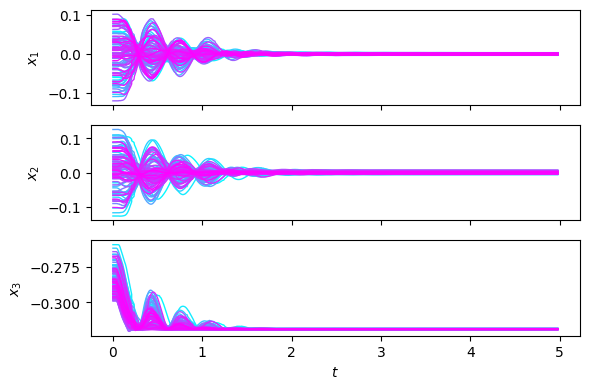

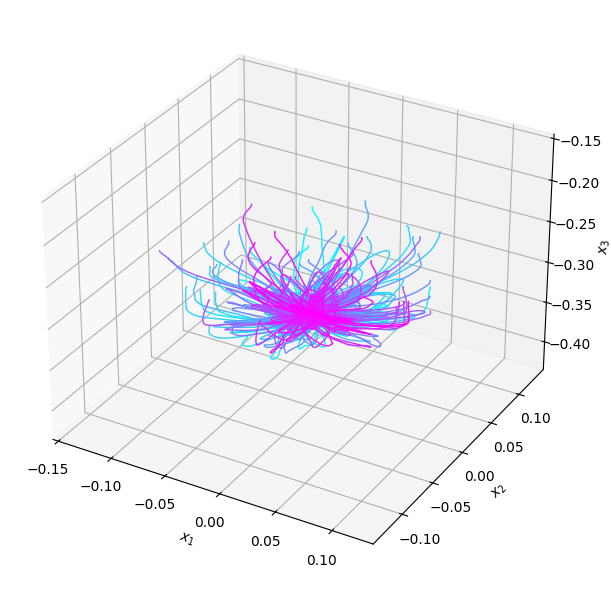

In [265]:
# Plot everything
plot_trajectories(aut_trajs[:, -3:], tss[0, :])

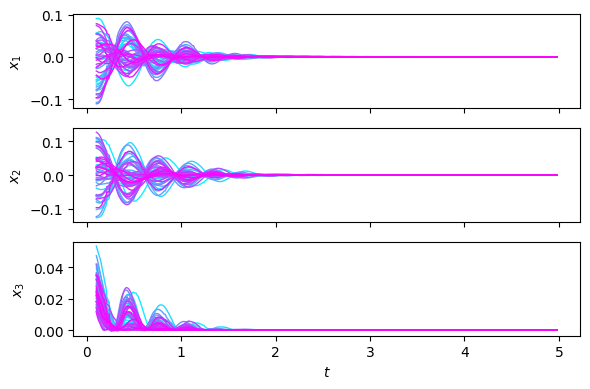

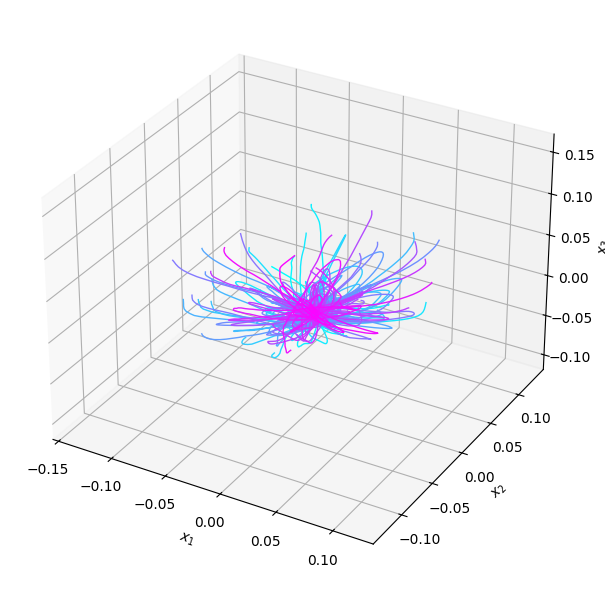

In [266]:
# Based on the plots, we choose an appropriate truncation point
i_trunc = 10  # 10

N_train = 50  # Number of training trajectories
aut_trajs_obs = aut_trajs[:N_train, -3:, i_trunc:] - aut_trajs[:N_train, -3:, -1:]  # shift to be zero centered
ts = tss[0, i_trunc:]

plot_trajectories(aut_trajs_obs, ts)

In [267]:
ssm_orth = DelaySSM(aut_trajs_obs=aut_trajs_obs,
                     SSMDim=5,
                     SSMOrder=2,
                     ROMOrder=2,
                     N_delay=3,
                     N_obs_delay=3,
                     orthogonalize=True,
                     ts=ts)

INFO   2025-08-13 08:44:01 ridge Transforming data
INFO   2025-08-13 08:44:01 ridge Skipping CV on ridge regression
INFO   2025-08-13 08:44:01 ridge Using polynomial features degree 2
INFO   2025-08-13 08:44:01 ridge Fitting regression model
INFO   2025-08-13 08:44:01 ridge Transforming data
INFO   2025-08-13 08:44:01 ridge Skipping CV on ridge regression
INFO   2025-08-13 08:44:01 ridge Using polynomial features degree 2
INFO   2025-08-13 08:44:01 ridge Fitting regression model
INFO   2025-08-13 08:44:01 ridge Transforming data
INFO   2025-08-13 08:44:01 ridge Skipping CV on ridge regression
INFO   2025-08-13 08:44:01 ridge Using polynomial features degree 2
INFO   2025-08-13 08:44:01 ridge Fitting regression model
INFO   2025-08-13 08:44:01 ridge Transforming data
INFO   2025-08-13 08:44:01 ridge Skipping CV on ridge regression
INFO   2025-08-13 08:44:01 ridge Using polynomial features degree 2
INFO   2025-08-13 08:44:01 ridge Fitting regression model


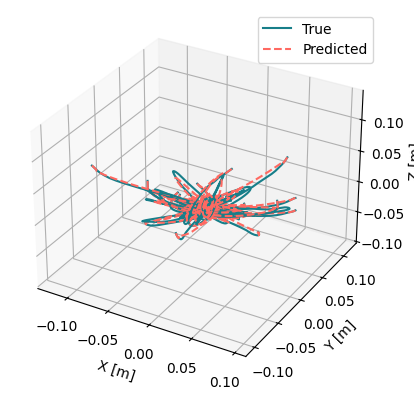

In [268]:
N_test = 20  # Number of test trajectories
aut_trajs_obs_test = aut_trajs[N_train:N_train+N_test, -3:, i_trunc:] - aut_trajs[N_train:N_train+N_test, -3:, -1:]

aut_trajs_pred = generate_ssm_predictions(ssm_orth, aut_trajs_obs_test, ts)
plot_trajectories_comparison(aut_trajs_obs_test[:, :, :], aut_trajs_pred, plot_errors=False)

In [ ]:
# We load the controlled data
# data_path_controlled = "../data/trajectories/controlled/real-1007-rw"  # random walk data (6 inputs)
data_path_controlled = "../data/trajectories/controlled/real-1208-circle"  # quasiperiodic data (6 inputs)

controlled_trajectories, controls, controlled_time_arrays = preprocess_trajectories(data_path_controlled, filter_transition=False)

# Combine trajectories into a single array
controlled_trajs, control_inputs, c_tss = combine_trajectories(controlled_trajectories, controls, controlled_time_arrays)

Processed ../data/trajectories/controlled/real-1007/20250710_181547_data_3.csv: 3976 time steps
Processed ../data/trajectories/controlled/real-1007/20250710_174112_data_28.csv: 3981 time steps
Processed ../data/trajectories/controlled/real-1007/20250710_174112_data_33.csv: 3979 time steps
Processed ../data/trajectories/controlled/real-1007/20250710_174112_data_34.csv: 3980 time steps
Processed ../data/trajectories/controlled/real-1007/20250710_181547_data_12.csv: 3979 time steps
Processed ../data/trajectories/controlled/real-1007/20250710_181547_data_7.csv: 3980 time steps
Processed ../data/trajectories/controlled/real-1007/20250710_181547_data_16.csv: 3978 time steps
Processed ../data/trajectories/controlled/real-1007/20250710_181547_data_14.csv: 3980 time steps
Processed ../data/trajectories/controlled/real-1007/20250710_181547_data_40.csv: 3980 time steps
Processed ../data/trajectories/controlled/real-1007/20250710_174112_data_3.csv: 3979 time steps
Processed ../data/trajectories/co

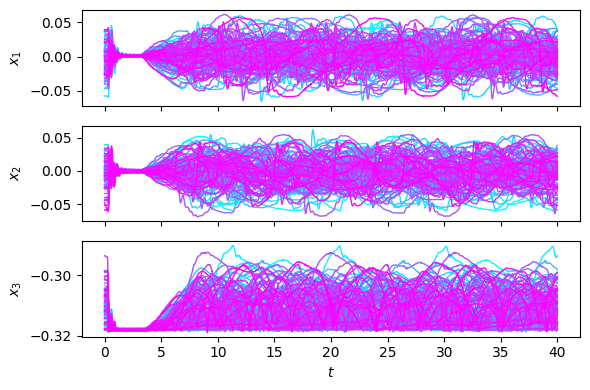

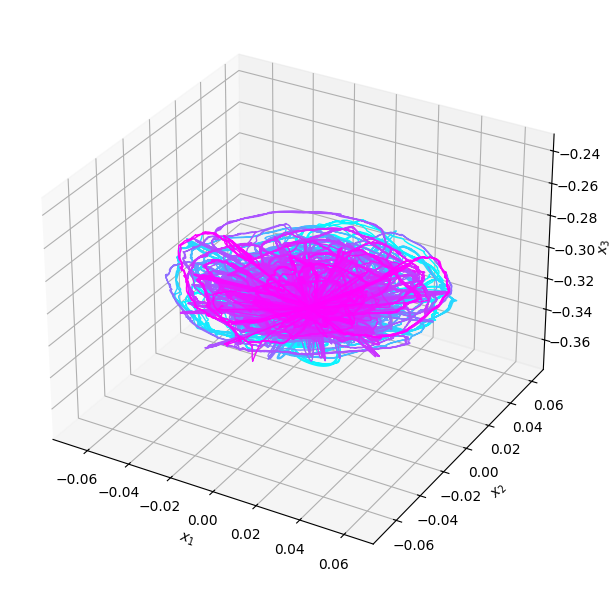

In [270]:
plot_trajectories(controlled_trajs[:, -3:], c_tss[0, :])

In [271]:
trajss = controlled_trajs[:, -3:,1300:]

if False:
    for trajss_idx in range(50):
        plt.figure()
        print("trajss_idx:", trajss_idx)
        plt.plot(trajss[trajss_idx, 0, :], trajss[trajss_idx, 1, :], label='Trajectory 1')
        plt.show()

    filtered_trajs = [0,1,6,11,15,16,17,22,27,36,42,43,46]
    controlled_trajs = controlled_trajs[filtered_trajs]
    control_inputs = control_inputs[filtered_trajs]

In [272]:
# Get an estimate of the rest positions
rest_positions = np.mean(aut_trajs[:, -3:, -1], axis=0)
# rest_positions[0:2] = 0
print("Rest positions:", rest_positions)

# Skip first data point as it's duplicate
i_skip = 1300
N_ctrl_train = 50
ctrl_trajs_obs = controlled_trajs[:N_ctrl_train, -3:, i_skip:] - rest_positions[None, :, None]
us = control_inputs[:N_ctrl_train, :, i_skip:]
ts = c_tss[1, i_skip:]

Rest positions: [-0.00070607  0.00062838 -0.31878878]


In [273]:
# Obtain labels used to fit B_r
xs_flat, us_flat, delta_x_dots_flat = get_residual_labels(ssm_orth, ctrl_trajs_obs, ts, us=us)

In [274]:
# Fit the residual model
poly_B_r = PolyBr(5, 6, 0, 0)
poly_B_r.fit(xs_flat, us_flat, delta_x_dots_flat)
residual_B_r = ResidualBr(poly_B_r)
obs_perf_matrix = jnp.zeros((3, (ssm_orth.N_obs_delay + 1) * 3))
obs_perf_matrix = obs_perf_matrix.at[:, 0:3].set(jnp.eye(3))
ssmr_orth = SSMR(ssm_orth, residual_B_r, obs_perf_matrix)

In [275]:
# Check B_r matrix
ssmr_orth.residual_dynamics.learned_B_r.B_r_coeff

Array([[-5.5669126e-04, -9.6794119e-04, -8.4368250e-05,  2.0702807e-03,
         5.7128805e-04, -1.0735078e-03],
       [-9.1753691e-04,  2.0656588e-04,  2.1472259e-03,  8.0329439e-05,
        -1.0007427e-03, -8.3426340e-04],
       [ 2.1661178e-04,  2.0215980e-04,  1.3301728e-04, -7.3800946e-04,
         4.0737687e-05, -1.2930579e-04],
       [-8.5910346e-05,  1.6400240e-04,  3.9771083e-04, -2.4624538e-04,
        -2.6029063e-04, -2.3147873e-05],
       [ 2.2349117e-04,  1.5376232e-04, -2.3437801e-04, -3.7916837e-04,
         3.4262248e-05,  2.7455765e-04]], dtype=float32)

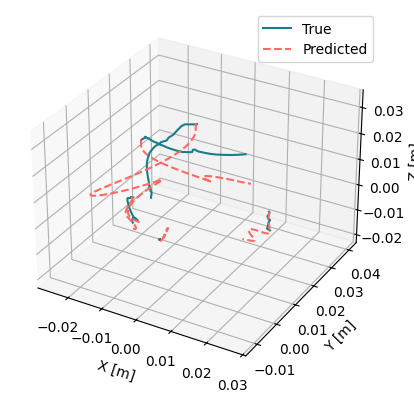

In [276]:
N_ctrl_test = 5
i_end = i_skip + 100
ctrl_trajs_obs_test = controlled_trajs[N_ctrl_train:N_ctrl_train+N_ctrl_test, -3:, i_skip:i_end] - rest_positions[None, :, None]
us_test = control_inputs[N_ctrl_train:N_ctrl_train+N_ctrl_test, :, i_skip:i_end]

ctrl_trajs_pred = generate_ssmr_predictions(ssmr_orth, ctrl_trajs_obs_test, ts, us=us_test)
plot_trajectories_comparison(ctrl_trajs_obs_test[:, :, :], ctrl_trajs_pred, plot_errors=False)

In [277]:
rmse = jnp.linalg.norm(ctrl_trajs_obs_test - ctrl_trajs_pred)
print(rmse)

0.24398376


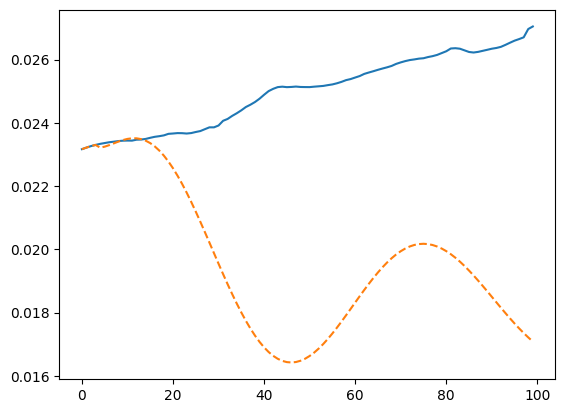

In [278]:
plt.plot(ctrl_trajs_obs_test[0,0,:], label='Observed')
plt.plot(ctrl_trajs_pred[0,0,:], '--', label='Predicted')

In [279]:
import os

# Save SSMR model
model_path = "../data/models/ssm/ssmr_orth_baseline.npz"
if os.path.exists(model_path) and False:
    raise FileExistsError(f"File '{model_path}' already exists.")

ssmr_orth.save_model(model_path)